## About this review copy

Upstream stock completion and linkage, with retained safe cached results.

Prepared from existing source and saved outputs; **no research calculations were rerun**. Address-level tables, interactive payloads and personal paths have been removed where detected. Static PNG plots are retained unchanged. Source markdown may describe earlier runs: consult [interpretation notes](../../docs/INTERPRETATION.md) and the saved outputs together. Input data are intentionally excluded.


In [ ]:
# Review copy: read the saved outputs without executing the research pipeline.
import os
if os.environ.get("ENERMAP_ENABLE_MODEL_RUN") != "1":
    raise RuntimeError("This showcase contains saved outputs. Raw data and third-party engines are excluded. Read the notebook; do not Run All for the presentation.")
import sys
from pathlib import Path
_repo = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "config.py").exists())
sys.path.insert(0, str(_repo))


# 1 · Prepare inputs for stock synthesis

Builds the three files the MOSTLY AI notebook needs, from the **clean** EPC data:

| output | what it is |
|---|---|
| `data/epc_train.csv` | observed dwellings, training split |
| `data/epc_test.csv` | observed dwellings, held-out validation split |
| `data/epc_gap_seed.csv` | one seed row per dwelling that must be synthesised, carrying `LSOA` + `accommodation_type` |

**What changed against `epc_mostlyai_final.ipynb`:**

1. **Input is `processed_epc_data_clean.csv`**, which has real UPRNs. The original ran on
   `processed_epc_data.csv`, where 70% of UPRNs had been destroyed by Excel.
2. **LSOA is assigned spatially**, by point-in-polygon on the UPRN coordinate, instead of via the
   postcode lookup. The lookup CSV is Excel-truncated at row 1,048,575 and stops at `HP6 9DF`, so
   every KT24 postcode — the whole Horsley/Effingham ward — got no LSOA. That is why the original
   notebook found LSOAs `E01030441-443, 445-447` (Guildford 003A–003G) empty and had to borrow
   neighbour distributions for 3,898 households. They are not empty; they were mislabelled.
   Point-in-polygon is also more accurate in general, because postcodes straddle LSOA boundaries.
3. **The gap is derived from Census with explicit handling of negative residuals** — cells where
   observed EPC already exceeds the Census household count. The original did not surface these.
4. **UPRN is carried through as a column** rather than re-attached by merging on feature columns.
   The original's `drop_duplicates(subset=shared_cols)` merge assigns one UPRN per unique
   feature-combination, so observed rows sharing a signature get the wrong UPRN or none.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

pd.set_option('display.width', 170)
pd.set_option('display.max_columns', 40)

ROOT     = Path('..')
DATA     = Path('data'); DATA.mkdir(parents=True, exist_ok=True)
EPC_CLEAN = ROOT / 'processed_epc_data_clean.csv'
ACM_CSV   = ROOT / 'ACM.csv'
LSOA_SHP  = ROOT / 'guildford_LSOA' / 'guildford_lsoas.shp'
UPRN_ZIP  = ROOT / 'osopenuprn_202604_csv (1).zip'

FEATURES = ['accommodation_type', 'Heat system', 'wall_construction', 'wall_insulation',
            'glazing_type', 'roof_type', 'TENURE', 'age_band']
SEED = 42

## 1.1 Load the clean EPC dwellings

In [2]:
epc = pd.read_csv(EPC_CLEAN, dtype={'UPRN': str})
assert not epc['UPRN'].dropna().str.contains('E', case=False, regex=False).any(), \
    'UPRNs are mangled — do not proceed'
print(f'{len(epc):,} dwellings, {epc["UPRN"].nunique():,} distinct UPRNs, 0 mangled')
print(f'LSOA from the postcode lookup: {epc["LSOA"].notna().sum():,} '
      f'({epc["LSOA"].isna().sum():,} missing)')
epc.head(3)

[Review copy: address-level or identifier-bearing output omitted; calculation code is retained.]


[Review copy: address-level or identifier-bearing output omitted; calculation code is retained.]


## 1.2 Reassign LSOA spatially

Point-in-polygon on the UPRN coordinate. The result is cached to
`data/uprn_lsoa_spatial.parquet`; delete that file to force a rebuild (it re-scans the 616 MB
national UPRN zip and takes ~3 minutes).

In [3]:
cache = DATA / 'uprn_lsoa_spatial.parquet'

if cache.exists():
    uprn_lsoa = pd.read_parquet(cache)
    print(f'loaded cached UPRN -> LSOA ({len(uprn_lsoa):,} rows)')
else:
    import zipfile
    lsoa_poly = gpd.read_file(LSOA_SHP).to_crs(27700)
    want = set(epc['UPRN'].dropna())
    keep = []
    with zipfile.ZipFile(UPRN_ZIP) as zf:
        name = next(n for n in zf.namelist() if n.lower().endswith('.csv'))
        print('scanning', name, '...')
        with zf.open(name) as f:
            for chunk in pd.read_csv(f, chunksize=500_000,
                                     usecols=['UPRN', 'X_COORDINATE', 'Y_COORDINATE'],
                                     dtype={'UPRN': 'string'}):
                m = chunk['UPRN'].isin(want)
                if m.any():
                    keep.append(chunk.loc[m])
    co_ = pd.concat(keep, ignore_index=True)
    pts = gpd.GeoDataFrame(
        co_[['UPRN']],
        geometry=gpd.points_from_xy(co_['X_COORDINATE'], co_['Y_COORDINATE']), crs=27700)
    uprn_lsoa = (gpd.sjoin(pts, lsoa_poly[['LSOA', 'geometry']], how='left', predicate='within')
                 [['UPRN', 'LSOA']].dropna().drop_duplicates('UPRN'))
    uprn_lsoa['UPRN'] = uprn_lsoa['UPRN'].astype(str)
    uprn_lsoa.to_parquet(cache, index=False)
    print(f'built and cached ({len(uprn_lsoa):,} rows)')

[Review copy: address-level or identifier-bearing output omitted; calculation code is retained.]


In [4]:
epc = epc.merge(uprn_lsoa.rename(columns={'LSOA': 'LSOA_spatial'}), on='UPRN', how='left')

both = epc[epc['LSOA'].notna() & epc['LSOA_spatial'].notna()]
agree = (both['LSOA'] == both['LSOA_spatial']).sum()
print('LSOA source comparison')
print(f'  postcode lookup     : {epc["LSOA"].notna().sum():,}')
print(f'  spatial join        : {epc["LSOA_spatial"].notna().sum():,}')
print(f'  recovered by spatial: {(epc["LSOA"].isna() & epc["LSOA_spatial"].notna()).sum():,}')
print(f'  agreement where both: {agree:,}/{len(both):,} ({100*agree/len(both):.2f}%)')

# Spatial wins; fall back to the lookup only where the point could not be placed.
epc['LSOA'] = epc['LSOA_spatial'].fillna(epc['LSOA'])
epc = epc.drop(columns='LSOA_spatial')

before = len(epc)
epc = epc[epc['LSOA'].notna()].copy()
print(f'\nDropped {before-len(epc):,} dwellings with no LSOA from any source.')
print(f'{len(epc):,} dwellings across {epc["LSOA"].nunique()} LSOAs')

[Review copy: address-level or identifier-bearing output omitted; calculation code is retained.]


In [5]:
# The seven LSOAs the original notebook had to neighbour-borrow
recovered = ['E01030441', 'E01030442', 'E01030443', 'E01030444',
             'E01030445', 'E01030446', 'E01030447']
cnt = epc.groupby('LSOA').size()
print('Guildford 003A-003G (Horsleys / Effingham), KT24 postcodes:')
for l in recovered:
    print(f'  {l}: {cnt.get(l, 0):>5} observed dwellings')
print(f'\nTotal recovered from these LSOAs: {sum(cnt.get(l,0) for l in recovered):,}')
print(f'\nRecords per LSOA — min {cnt.min()}, median {cnt.median():.0f}, max {cnt.max()}')

Guildford 003A-003G (Horsleys / Effingham), KT24 postcodes:
  E01030441:   393 observed dwellings
  E01030442:   293 observed dwellings
  E01030443:   311 observed dwellings
  E01030444:   513 observed dwellings
  E01030445:   491 observed dwellings
  E01030446:   312 observed dwellings
  E01030447:   346 observed dwellings

Total recovered from these LSOAs: 2,659

Records per LSOA — min 231, median 462, max 1226


## 1.3 Census control totals

`ACM.csv` is Census 2021 TS044. The four flat categories (purpose-built, converted house, other
converted, commercial building) are summed to match the single `Flat` class the EPC classifier
produces — EPC cannot distinguish them.

In [6]:
acm = pd.read_csv(ACM_CSV)
acm.columns = [c.strip() for c in acm.columns]
numcols = [c for c in acm.columns if c not in ('geography', 'LSOA')]
for c in numcols:
    acm[c] = pd.to_numeric(acm[c], errors='coerce')

flat_cols = [c for c in numcols if ('flats' in c) or ('converted' in c) or ('commercial' in c)]
caravan_cols = [c for c in numcols if 'caravan' in c.lower()]

census = pd.DataFrame({
    'LSOA': acm['LSOA'],
    'Detached': acm['Detached'],
    'Semi-detached': acm['Semi-detached'],
    'Terraced': acm['Terraced'],
    'Flat': acm[flat_cols].sum(axis=1),
    'Caravan or mobile': acm[caravan_cols].sum(axis=1),
}).set_index('LSOA')

print(f'{len(census)} LSOAs, {census.values.sum():,} households')
print(census.sum().to_string())
assert census.values.sum() == acm['All households'].sum(), 'category sum != All households'

84 LSOAs, 55,754 households
Detached             18666
Semi-detached        18177
Terraced              7589
Flat                 10858
Caravan or mobile      464


## 1.4 Reconcile observed against Census, and derive the gap

A **negative residual** is a cell where the EPC data already contains more dwellings than the
Census counts households. That is not an error in the EPC: the Census counts *households*, and so
excludes vacant dwellings, second homes, and — most importantly here — communal establishments
such as halls of residence. Guildford has a large university.

Those cells are clamped to zero: nothing is synthesised there, and the observed records are kept.
The consequence is that the completed stock finishes slightly **above** the Census household
total, which is correct for a *dwelling* stock model even though it does not tie to Census.

If you want it to tie exactly, swap the control total for VOA council-tax dwelling counts per
LSOA and keep ACM only for the accommodation-type proportions.

In [7]:
observed = (epc.pivot_table(index='LSOA', columns='accommodation_type',
                            values='UPRN', aggfunc='count')
            .reindex(columns=census.columns, fill_value=0)
            .reindex(census.index, fill_value=0)
            .fillna(0).astype(int))

residual = census - observed
neg = residual < 0

print(f'Census households : {census.values.sum():,}')
print(f'EPC observed      : {observed.values.sum():,}')
print(f'Net residual      : {residual.values.sum():,}')
print()
print(f'Cells where observed > census: {neg.values.sum()} of {residual.size}')
print(f'  total over-count           : {int(-residual.values[residual.values < 0].sum()):,}')

gap = residual.clip(lower=0)
print(f'\nGap after clamping negatives to 0: {gap.values.sum():,}')
print(f'Implied completed stock         : {observed.values.sum() + gap.values.sum():,} '
      f'(Census {census.values.sum():,}, +{observed.values.sum()+gap.values.sum()-census.values.sum():,})')

summary = pd.DataFrame({
    'census': census.sum(), 'observed': observed.sum(),
    'net_residual': residual.sum(), 'gap_clamped': gap.sum(),
    'n_lsoa_negative': neg.sum(),
})
print()
print(summary.to_string())

Census households : 55,754
EPC observed      : 40,802
Net residual      : 14,952

Cells where observed > census: 58 of 420
  total over-count           : 1,541

Gap after clamping negatives to 0: 16,493
Implied completed stock         : 57,295 (Census 55,754, +1,541)

                   census  observed  net_residual  gap_clamped  n_lsoa_negative
Detached            18666     10858          7808         7907                3
Semi-detached       18177     11856          6321         6395                2
Terraced             7589      7151           438         1041               29
Flat                10858     10865            -7          757               23
Caravan or mobile     464        72           392          393                1


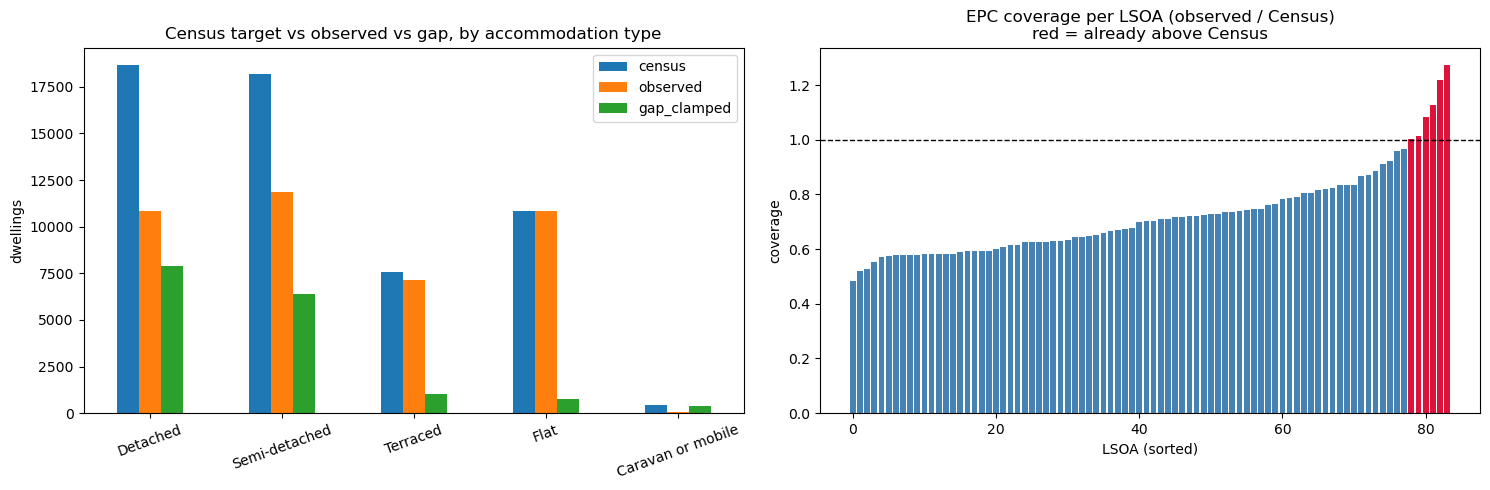

coverage: min 0.48, median 0.70, max 1.27
LSOAs already at/above Census: 6 of 84


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

summary[['census', 'observed', 'gap_clamped']].plot.bar(ax=axes[0], rot=20)
axes[0].set_title('Census target vs observed vs gap, by accommodation type')
axes[0].set_ylabel('dwellings')

cov = (observed.sum(axis=1) / census.sum(axis=1)).sort_values()
axes[1].bar(range(len(cov)), cov.values,
            color=['crimson' if v > 1 else 'steelblue' for v in cov.values])
axes[1].axhline(1.0, color='k', ls='--', lw=1)
axes[1].set_title('EPC coverage per LSOA (observed / Census)\nred = already above Census')
axes[1].set_xlabel('LSOA (sorted)'); axes[1].set_ylabel('coverage')

plt.tight_layout(); plt.show()

print(f'coverage: min {cov.min():.2f}, median {cov.median():.2f}, max {cov.max():.2f}')
print(f'LSOAs already at/above Census: {(cov >= 1).sum()} of {len(cov)}')

## 1.5 Build the gap seed

One row per dwelling to be synthesised, carrying only the two columns the generator is
conditioned on. MOSTLY AI fills the remaining six features from the learnt joint distribution.

In [9]:
gap_seed = (gap.stack().rename('n').reset_index()
            .rename(columns={'level_1': 'accommodation_type'}))
gap_seed = gap_seed.loc[gap_seed['n'] > 0]
gap_seed = gap_seed.loc[gap_seed.index.repeat(gap_seed['n'])][['LSOA', 'accommodation_type']]
gap_seed = gap_seed.reset_index(drop=True)

print(f'{len(gap_seed):,} seed rows')
print(gap_seed['accommodation_type'].value_counts().to_string())
print(f'\nLSOAs covered: {gap_seed["LSOA"].nunique()} of {len(census)}')
gap_seed.head()

16,493 seed rows
accommodation_type
Detached             7907
Semi-detached        6395
Terraced             1041
Flat                  757
Caravan or mobile     393

LSOAs covered: 83 of 84


,LSOA,accommodation_type
0,E01030422,Detached
1,E01030422,Detached
2,E01030422,Detached
3,E01030422,Detached
4,E01030422,Detached


## 1.6 Train / test split

Stratified by LSOA so every LSOA appears in training — the generator is conditioned on LSOA, and
an unseen level at generation time has nothing to draw from.

In [10]:
train_parts, test_parts = [], []
rng = np.random.default_rng(SEED)

for lsoa_code, grp in epc.groupby('LSOA'):
    grp = grp.sample(frac=1.0, random_state=SEED)
    n_test = int(round(0.20 * len(grp)))
    n_test = min(n_test, max(0, len(grp) - 1))   # always leave >=1 row for training
    test_parts.append(grp.iloc[:n_test])
    train_parts.append(grp.iloc[n_test:])

train = pd.concat(train_parts).sample(frac=1.0, random_state=SEED).reset_index(drop=True)
test  = pd.concat(test_parts).sample(frac=1.0, random_state=SEED).reset_index(drop=True)

print(f'train {len(train):,} rows | {train["LSOA"].nunique()} LSOAs')
print(f'test  {len(test):,} rows | {test["LSOA"].nunique()} LSOAs')
assert train['LSOA'].nunique() == epc['LSOA'].nunique(), 'an LSOA is missing from train'
assert set(train['UPRN']) & set(test['UPRN']) == set(), 'train/test overlap'

train 32,720 rows | 84 LSOAs
test  8,183 rows | 84 LSOAs


In [11]:
# TENURE and age_band carry a few nulls; MOSTLY AI handles them, but make the
# level explicit so 'Unknown' is a modelled category rather than a silent NaN.
for df in (train, test):
    df['TENURE'] = df['TENURE'].fillna('Unknown')
    df['age_band'] = df['age_band'].fillna('Unknown')

TRAIN_COLS = FEATURES + ['LSOA']      # POSTCODE and UPRN excluded from training
train[TRAIN_COLS + ['UPRN']].to_csv(DATA / 'epc_train.csv', index=False)
test[TRAIN_COLS + ['UPRN']].to_csv(DATA / 'epc_test.csv', index=False)
gap_seed.to_csv(DATA / 'epc_gap_seed.csv', index=False)

census.to_csv(DATA / 'census_targets.csv')
observed.to_csv(DATA / 'observed_counts.csv')

print('wrote:')
for f in ['epc_train.csv', 'epc_test.csv', 'epc_gap_seed.csv',
          'census_targets.csv', 'observed_counts.csv']:
    p = DATA / f
    print(f'  {p}  ({p.stat().st_size/1e3:.0f} KB)')

print()
print('TRAINING COLUMNS:', TRAIN_COLS)
print('(UPRN is written alongside for re-attachment but must NOT be a training feature)')

[Review copy: address-level or identifier-bearing output omitted; calculation code is retained.]


## Summary

The generator is trained on the eight feature columns plus `LSOA`. `UPRN` travels with the
observed rows so it can be reattached directly after synthesis — no merge-on-features needed —
and `POSTCODE` is dropped entirely (it is a high-cardinality string that adds nothing once LSOA
is present, and it crashed the original run on Windows).

Next: `02_synthesise_mostlyai.ipynb`.